# 🤖 Future of Jobs & AI Impact — Full ML Pipeline
## Phase 1 → Phase 2 → Phase 3: EDA ▸ Data Preparation ▸ Feature Engineering

**Dataset:** Future_of_Jobs_AI_Dataset.csv  
**Target Variable:** `job_survival_class` (0 = At Risk, 1 = Stable, 2 = Growing)  
**Pipeline covers:**
- ✅ Phase 1 recap (EDA summary)  
- ✅ Phase 2: Data Preparation — cleaning, encoding, skewness, scaling, class balancing  
- ✅ Phase 3: Feature Engineering — new features, selection (importance + PCA), train/test split  


---
## 📦 Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import skew, boxcox
from scipy.special import inv_boxcox

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans"
})

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


---
## 📂 Load Dataset

In [2]:
df_raw = pd.read_csv("Future_of_Jobs_AI_Dataset.csv")
df = df_raw.copy()

print(f"Dataset shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head(5)

Dataset shape  : 12,343 rows × 13 columns
Memory usage   : 5322.3 KB


,job_title,country,experience_level,education_level,year,salary,ai_risk_score,primary_skill,skill_demand_score,job_openings,job_survival_class,salary_bucket,ai_risk_category
0,Data Scientist,USA,Senior,Master,2022,61931.030,0.320,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.840,0.520,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.170,0.250,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.860,0.440,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.260,0.750,SQL,61,3433,0,Medium,High Risk


---
## 🔍 Phase 1 Recap — EDA Highlights

Before moving to preparation we briefly re-surface the critical findings from Phase 1 that directly drive our Phase 2 decisions.


In [3]:
# ── Schema ──
print("=" * 55)
print("COLUMN TYPES")
print("=" * 55)
df.info()
print()

# ── Missingness ──
print("=" * 55)
print("MISSING VALUES")
print("=" * 55)
miss = df.isnull().sum()
print(miss[miss > 0] if miss.sum() > 0 else "  ✅ No missing values found.")

COLUMN TYPES
<class 'pandas.DataFrame'>
RangeIndex: 12343 entries, 0 to 12342
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_title           12343 non-null  str    
 1   country             12343 non-null  str    
 2   experience_level    12343 non-null  str    
 3   education_level     12343 non-null  str    
 4   year                12343 non-null  int64  
 5   salary              12343 non-null  float64
 6   ai_risk_score       12343 non-null  float64
 7   primary_skill       12343 non-null  str    
 8   skill_demand_score  12343 non-null  int64  
 9   job_openings        12343 non-null  int64  
 10  job_survival_class  12343 non-null  int64  
 11  salary_bucket       12343 non-null  str    
 12  ai_risk_category    12343 non-null  str    
dtypes: float64(2), int64(4), str(7)
memory usage: 1.2 MB

MISSING VALUES
  ✅ No missing values found.


In [4]:
# ── Duplicates ──
dupes = df.duplicated().sum()
print(f"Duplicate rows : {dupes}")

# ── Target distribution ──
print()
print("TARGET  →  job_survival_class")
print("-" * 35)
counts = df['job_survival_class'].value_counts().sort_index()
labels = {0: "At Risk", 1: "Stable", 2: "Growing"}
for k, v in counts.items():
    bar = "█" * (v // 100)
    print(f"  Class {k} ({labels[k]:8s})  {v:5d}  {bar}")
print()

# ── Skewness of numerics ──
num_cols_base = ['salary', 'ai_risk_score', 'skill_demand_score', 'job_openings']
print("SKEWNESS (|skew| > 0.5 needs treatment)")
print("-" * 35)
for c in num_cols_base:
    s = skew(df[c])
    flag = "⚠️  moderate skew" if abs(s) >= 0.5 else "✅ approx. normal"
    print(f"  {c:<22} skew = {s:+.3f}  {flag}")

Duplicate rows : 0

TARGET  →  job_survival_class
-----------------------------------
  Class 0 (At Risk )   1355  █████████████
  Class 1 (Stable  )   5806  ██████████████████████████████████████████████████████████
  Class 2 (Growing )   5182  ███████████████████████████████████████████████████

SKEWNESS (|skew| > 0.5 needs treatment)
-----------------------------------
  salary                 skew = +0.783  ⚠️  moderate skew
  ai_risk_score          skew = +0.650  ⚠️  moderate skew
  skill_demand_score     skew = +0.011  ✅ approx. normal
  job_openings           skew = +0.044  ✅ approx. normal


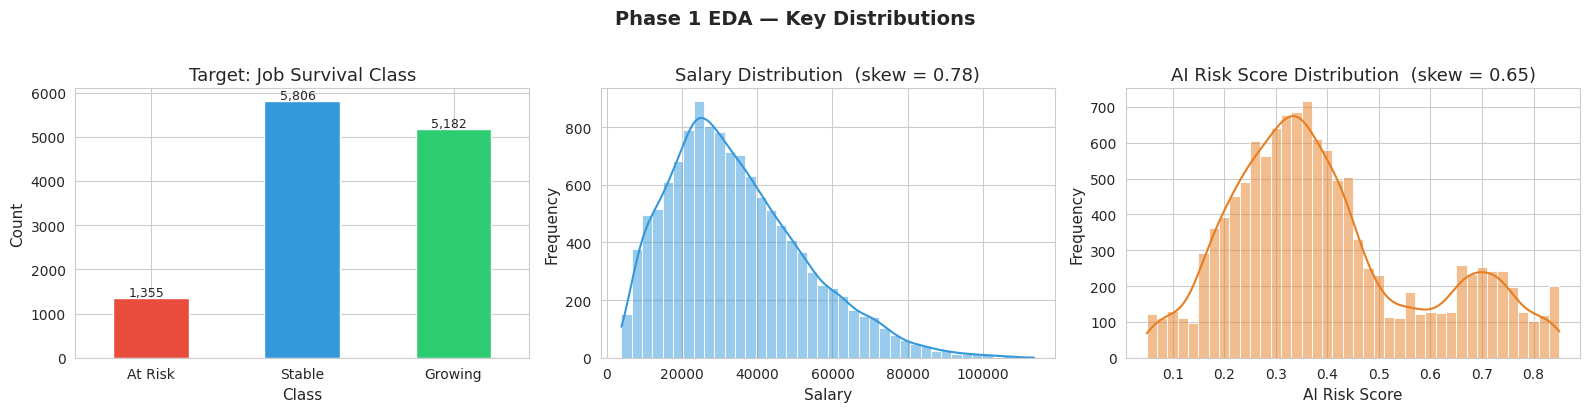

In [5]:
# ── Visual EDA recap: target + top 2 numeric distributions ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Target
counts.rename(index=labels).plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[0].set_title("Target: Job Survival Class")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x()+0.1, p.get_height()+50), fontsize=9)

# Salary
sns.histplot(df['salary'], kde=True, bins=40, ax=axes[1], color='#3498db')
axes[1].set_title(f"Salary Distribution  (skew = {skew(df['salary']):.2f})")
axes[1].set_xlabel("Salary"); axes[1].set_ylabel("Frequency")

# AI Risk
sns.histplot(df['ai_risk_score'], kde=True, bins=40, ax=axes[2], color='#e67e22')
axes[2].set_title(f"AI Risk Score Distribution  (skew = {skew(df['ai_risk_score']):.2f})")
axes[2].set_xlabel("AI Risk Score"); axes[2].set_ylabel("Frequency")

plt.suptitle("Phase 1 EDA — Key Distributions", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 🛠️ Phase 2 — Data Preparation

### Roadmap
1. Drop leaky / redundant columns  
2. Ordinal encoding  
3. One-Hot encoding  
4. Skewness treatment (log / Box-Cox)  
5. Outlier analysis  
6. Feature scaling (RobustScaler)  
7. Class imbalance: SMOTE + Tomek Links  
8. Train / Validation / Test split  


### 2.1 Identify & Drop Leaky / Redundant Columns

In [6]:
# 'salary_bucket' is a direct binning of 'salary'  →  leakage for regression targets
# 'ai_risk_category' is a binning of 'ai_risk_score'  →  leakage
# We KEEP them as intermediate reference but drop from the modelling matrix later.

LEAKY_COLS = ['salary_bucket', 'ai_risk_category']

print("Leaky / redundant columns identified:")
for c in LEAKY_COLS:
    print(f"  ✗  {c}")
print()
print("These will be EXCLUDED from the feature matrix X but are kept in df for reference.")

Leaky / redundant columns identified:
  ✗  salary_bucket
  ✗  ai_risk_category

These will be EXCLUDED from the feature matrix X but are kept in df for reference.


### 2.2 Ordinal Encoding — Preserving Natural Order

In [7]:
# Experience Level: Entry < Mid < Senior
EXPERIENCE_MAP = {'Entry': 0, 'Mid': 1, 'Senior': 2}

# Education Level: Bachelor < Master < PhD
EDUCATION_MAP = {'Bachelor': 0, 'Master': 1, 'PhD': 2}

# AI Risk Category (reference — derived from ai_risk_score)
AI_RISK_MAP = {'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2}

# Salary Bucket (reference only)
SALARY_BUCKET_MAP = {'Low': 0, 'Medium': 1, 'High': 2}

df['experience_encoded']   = df['experience_level'].map(EXPERIENCE_MAP)
df['education_encoded']    = df['education_level'].map(EDUCATION_MAP)
df['ai_risk_cat_encoded']  = df['ai_risk_category'].map(AI_RISK_MAP)
df['salary_bucket_encoded']= df['salary_bucket'].map(SALARY_BUCKET_MAP)

print("Ordinal encoding applied:")
print(df[['experience_level','experience_encoded',
          'education_level','education_encoded']].drop_duplicates().sort_values('experience_encoded'))

Ordinal encoding applied:
   experience_level  experience_encoded education_level  education_encoded
3             Entry                   0             PhD                  2
5             Entry                   0          Master                  1
7             Entry                   0        Bachelor                  0
2               Mid                   1        Bachelor                  0
17              Mid                   1          Master                  1
23              Mid                   1             PhD                  2
0            Senior                   2          Master                  1
1            Senior                   2        Bachelor                  0
20           Senior                   2             PhD                  2


### 2.3 One-Hot Encoding — Nominal Categoricals

In [8]:
OHE_COLS = ['job_title', 'country', 'primary_skill']

df_encoded = pd.get_dummies(df, columns=OHE_COLS, drop_first=False, dtype=int)

# Show new columns created
new_cols = [c for c in df_encoded.columns if any(c.startswith(p+'_') for p in OHE_COLS)]
print(f"One-Hot encoded {len(OHE_COLS)} columns → {len(new_cols)} binary features:")
print("  ", new_cols)
print(f"\nDataFrame shape after OHE: {df_encoded.shape}")

One-Hot encoded 3 columns → 25 binary features:
   ['job_title_AI Researcher', 'job_title_Business Analyst', 'job_title_Cloud Engineer', 'job_title_Cybersecurity Analyst', 'job_title_Data Analyst', 'job_title_Data Scientist', 'job_title_DevOps Engineer', 'job_title_ML Engineer', 'job_title_Product Manager', 'job_title_Software Engineer', 'country_Australia', 'country_Canada', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'primary_skill_AWS', 'primary_skill_Deep Learning', 'primary_skill_Docker', 'primary_skill_Excel', 'primary_skill_Java', 'primary_skill_Python', 'primary_skill_SQL', 'primary_skill_Security', 'primary_skill_Strategy']

DataFrame shape after OHE: (12343, 39)


### 2.4 Skewness Treatment

  salary                skew before: +0.783  →  after log1p: -0.563


  ai_risk_score         skew before: +0.650  →  after log1p: +0.398


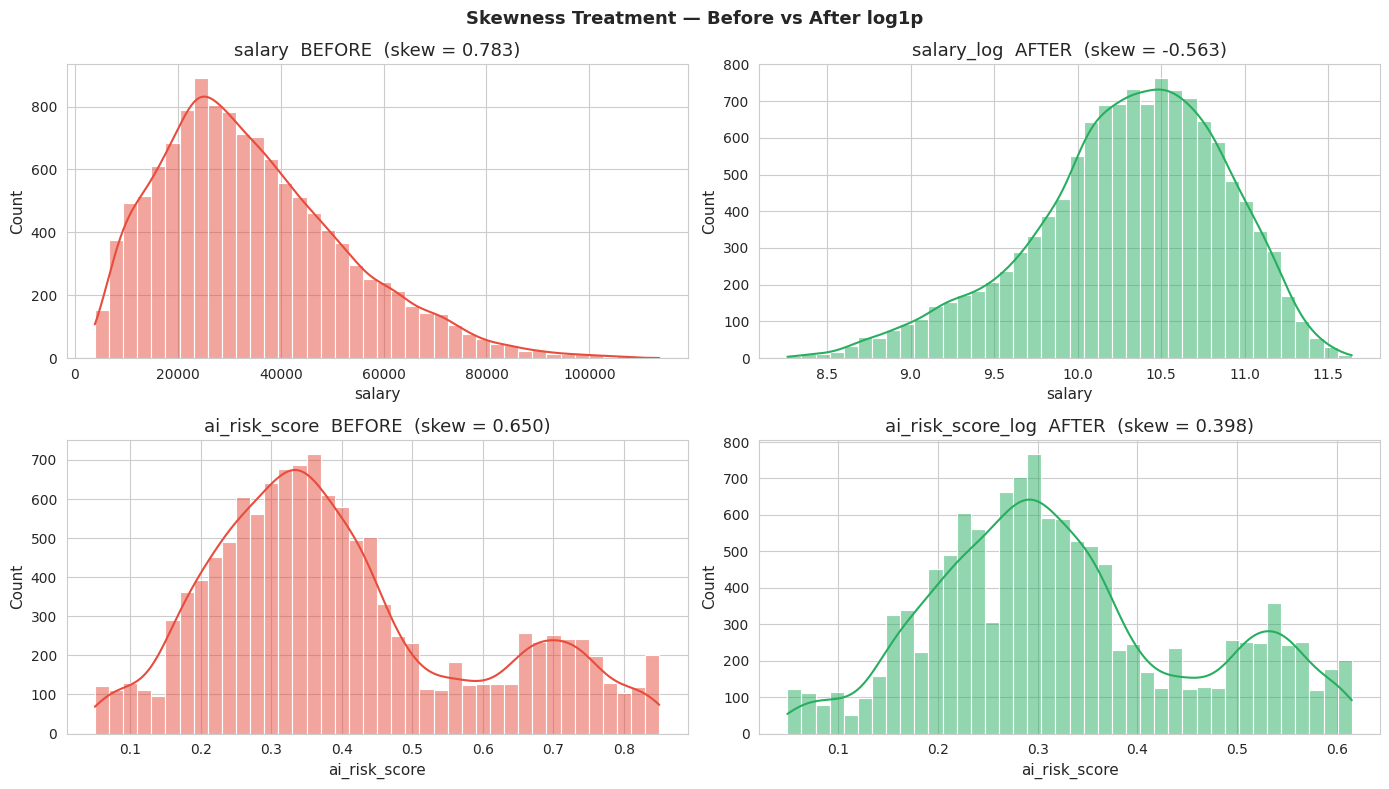


✅ Log-transformed columns replace originals in the modelling matrix.


In [9]:
# Threshold: |skew| > 0.5 = moderately skewed → apply log1p transformation
SKEW_THRESHOLD = 0.5
SKEW_COLS = ['salary', 'ai_risk_score']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(SKEW_COLS):
    before = skew(df_encoded[col])
    
    # Apply log1p (handles 0 and positive values safely)
    transformed = np.log1p(df_encoded[col])
    after = skew(transformed)
    
    df_encoded[col + '_log'] = transformed
    
    # Plot before
    sns.histplot(df_encoded[col], kde=True, ax=axes[i][0], color='#e74c3c', bins=40)
    axes[i][0].set_title(f"{col}  BEFORE  (skew = {before:.3f})")
    
    # Plot after
    sns.histplot(transformed, kde=True, ax=axes[i][1], color='#27ae60', bins=40)
    axes[i][1].set_title(f"{col}_log  AFTER  (skew = {after:.3f})")
    
    print(f"  {col:<20}  skew before: {before:+.3f}  →  after log1p: {after:+.3f}")

plt.suptitle("Skewness Treatment — Before vs After log1p", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Replace originals with log-transformed versions in model cols
df_encoded['salary']        = df_encoded['salary_log']
df_encoded['ai_risk_score'] = df_encoded['ai_risk_score_log']
df_encoded.drop(columns=['salary_log', 'ai_risk_score_log'], inplace=True)
print("\n✅ Log-transformed columns replace originals in the modelling matrix.")

### 2.5 Outlier Analysis

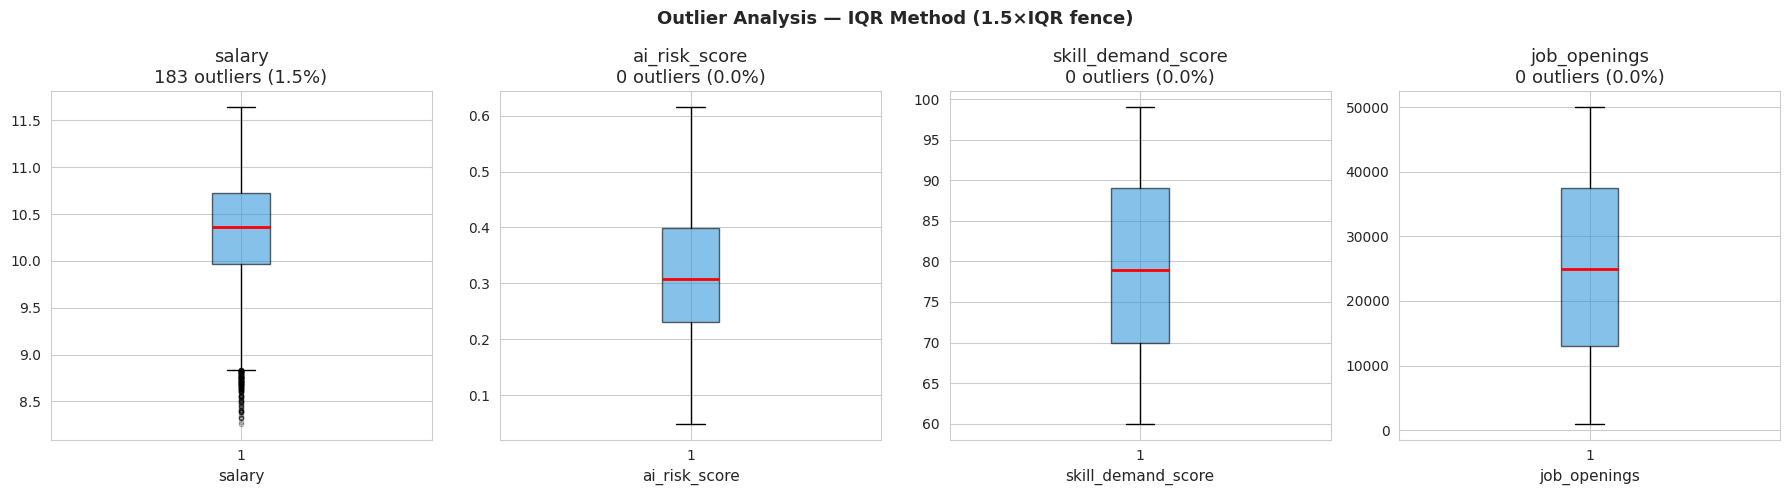

Outlier Summary (IQR method):
  Column                      Count        %   Lower Fence   Upper Fence
  ----------------------------------------------------------------------
  salary                        183    1.48%         8.838        11.851
  ai_risk_score                   0    0.00%        -0.020         0.650
  skill_demand_score              0    0.00%        41.500       117.500
  job_openings                    0    0.00%    -23678.250     74111.750

⚙️  Strategy: RobustScaler (uses median & IQR) — outliers are retained
   because they represent real salary extremes and valid risk scores.


In [10]:
NUM_COLS_ANALYSIS = ['salary', 'ai_risk_score', 'skill_demand_score', 'job_openings']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

outlier_summary = {}
for i, col in enumerate(NUM_COLS_ANALYSIS):
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_encoded[col] < lower) | (df_encoded[col] > upper)).sum()
    pct = n_out / len(df_encoded) * 100
    outlier_summary[col] = {'count': n_out, 'pct': pct, 'lower': lower, 'upper': upper}
    
    bp = axes[i].boxplot(df_encoded[col], patch_artist=True,
                         boxprops=dict(facecolor='#3498db', alpha=0.6),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', markersize=3, alpha=0.3))
    axes[i].set_title(f"{col}\n{n_out} outliers ({pct:.1f}%)")
    axes[i].set_xlabel(col)

plt.suptitle("Outlier Analysis — IQR Method (1.5×IQR fence)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Outlier Summary (IQR method):")
print(f"  {'Column':<25} {'Count':>7}  {'%':>7}  {'Lower Fence':>12}  {'Upper Fence':>12}")
print("  " + "-"*70)
for col, info in outlier_summary.items():
    print(f"  {col:<25} {info['count']:>7}  {info['pct']:>6.2f}%  {info['lower']:>12.3f}  {info['upper']:>12.3f}")
print()
print("⚙️  Strategy: RobustScaler (uses median & IQR) — outliers are retained")
print("   because they represent real salary extremes and valid risk scores.")

### 2.6 Feature Scaling — RobustScaler

Feature matrix  : 12,343 rows × 32 features
Target          : job_survival_class  |  classes: [np.int64(0), np.int64(1), np.int64(2)]



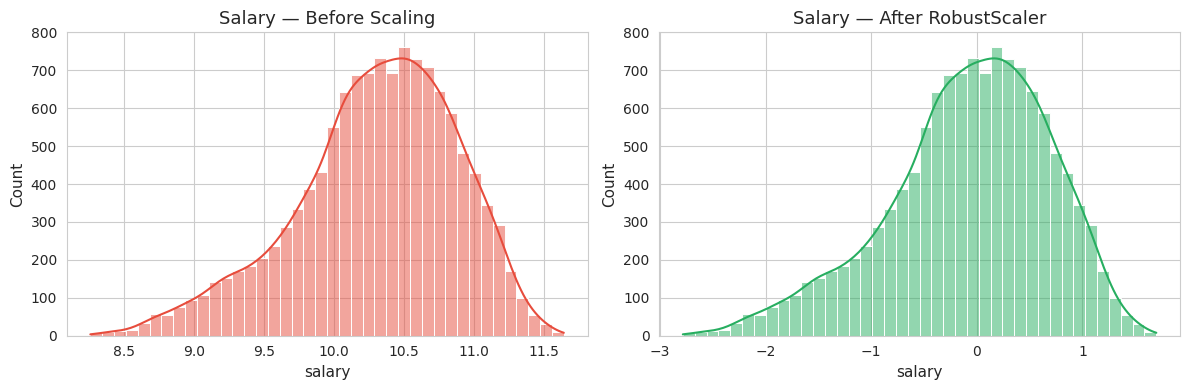

✅ RobustScaler applied. Median is now ~0, IQR range is ~[-1, 1].

Scaled salary stats:
count   12343.000
mean       -0.079
std         0.767
min        -2.785
25%        -0.521
50%         0.000
75%         0.479
max         1.700
Name: salary, dtype: float64


In [11]:
# Build the FINAL feature matrix (drop leaky + original string cols)
DROP_FOR_MODEL = ['experience_level', 'education_level', 'ai_risk_category',
                  'salary_bucket', 'ai_risk_cat_encoded', 'salary_bucket_encoded']

TARGET = 'job_survival_class'

feature_cols = [c for c in df_encoded.columns
                if c not in DROP_FOR_MODEL + [TARGET]
                and df_encoded[c].dtype in [np.int64, np.float64, bool, int, float]
                and c != TARGET]

X_raw = df_encoded[feature_cols].copy()
y     = df_encoded[TARGET].copy()

print(f"Feature matrix  : {X_raw.shape[0]:,} rows × {X_raw.shape[1]} features")
print(f"Target          : {TARGET}  |  classes: {sorted(y.unique())}")
print()

# RobustScaler: robust to outliers (uses median, IQR instead of mean, std)
scaler = RobustScaler()
X_scaled_arr = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled_arr, columns=feature_cols, index=X_raw.index)

# Compare distributions before/after for salary
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_raw['salary'], kde=True, ax=axes[0], bins=40, color='#e74c3c')
axes[0].set_title("Salary — Before Scaling")
sns.histplot(X_scaled['salary'], kde=True, ax=axes[1], bins=40, color='#27ae60')
axes[1].set_title("Salary — After RobustScaler")
plt.tight_layout()
plt.show()

print("✅ RobustScaler applied. Median is now ~0, IQR range is ~[-1, 1].")
print(f"\nScaled salary stats:\n{X_scaled['salary'].describe()}")

### 2.7 Class Imbalance — SMOTE + Tomek Links

Class imbalance ratios (relative to majority):
  Class 0 (At Risk ):  1355  ratio = 4.28x
  Class 1 (Stable  ):  5806  ratio = 1.00x
  Class 2 (Growing ):  5182  ratio = 1.12x

⚠️  Class 0 (At Risk) is severely underrepresented → SMOTE will synthesise minority samples
    Tomek Links then remove borderline majority samples to sharpen decision boundaries


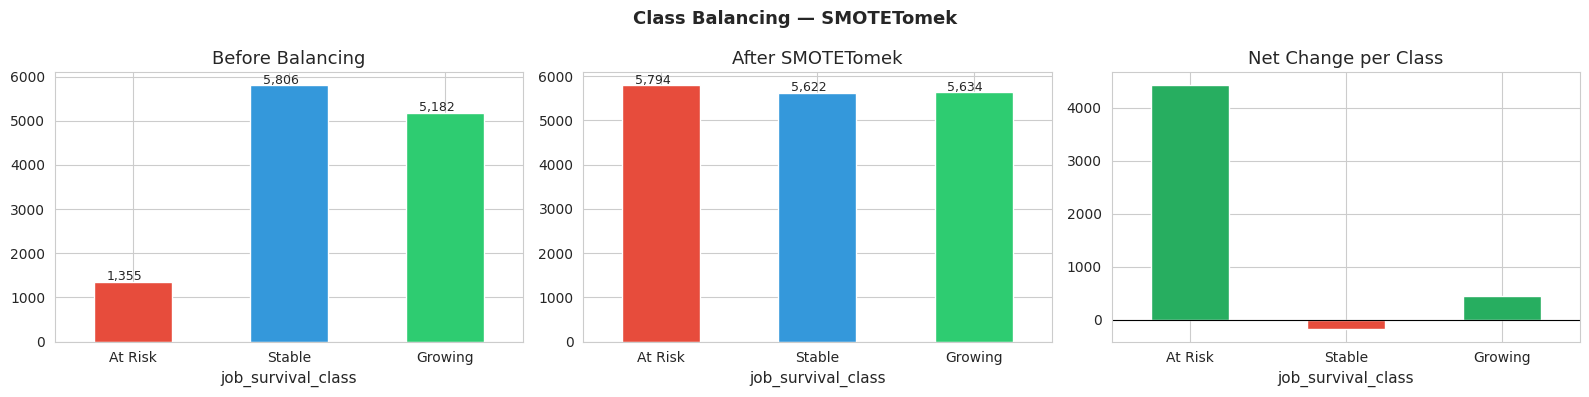


After SMOTETomek: 17,050 samples
  Class 0 (At Risk ): 5,794
  Class 1 (Stable  ): 5,622
  Class 2 (Growing ): 5,634


In [12]:
# ── Visualise imbalance ──
class_labels = {0: "At Risk", 1: "Stable", 2: "Growing"}
class_counts = y.value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Before
class_counts.rename(index=class_labels).plot(
    kind='bar', ax=axes[0], color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[0].set_title("Before Balancing")
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x()+0.08, p.get_height()+30), fontsize=9)

# Imbalance ratio
majority = class_counts.max()
print("Class imbalance ratios (relative to majority):")
for cls, cnt in class_counts.items():
    ratio = majority / cnt
    print(f"  Class {cls} ({class_labels[cls]:8s}): {cnt:5d}  ratio = {ratio:.2f}x")
print()
print("⚠️  Class 0 (At Risk) is severely underrepresented → SMOTE will synthesise minority samples")
print("    Tomek Links then remove borderline majority samples to sharpen decision boundaries")

# ── Apply SMOTETomek ──
smote_tomek = SMOTETomek(random_state=42)
X_balanced, y_balanced = smote_tomek.fit_resample(X_scaled, y)

balanced_counts = pd.Series(y_balanced).value_counts().sort_index()
balanced_counts.rename(index=class_labels).plot(
    kind='bar', ax=axes[1], color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[1].set_title("After SMOTETomek")
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}", (p.get_x()+0.08, p.get_height()+30), fontsize=9)

# Change
delta = balanced_counts - class_counts.reindex(balanced_counts.index, fill_value=0)
delta.rename(index=class_labels).plot(kind='bar', ax=axes[2],
    color=['#27ae60' if v >= 0 else '#e74c3c' for v in delta], edgecolor='white')
axes[2].set_title("Net Change per Class")
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle("Class Balancing — SMOTETomek", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nAfter SMOTETomek: {X_balanced.shape[0]:,} samples")
for cls, cnt in balanced_counts.items():
    print(f"  Class {cls} ({class_labels[cls]:8s}): {cnt:,}")

### 2.8 Train / Validation / Test Split

In [13]:
# 70% train | 15% validation | 15% test  — stratified
X_temp, X_test, y_temp, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.15, random_state=42, stratify=y_balanced)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)  # 0.1765 of 85% ≈ 15%

print("Split sizes:")
print(f"  Train       : {X_train.shape[0]:,} samples  ({X_train.shape[0]/X_balanced.shape[0]*100:.1f}%)")
print(f"  Validation  : {X_val.shape[0]:,} samples  ({X_val.shape[0]/X_balanced.shape[0]*100:.1f}%)")
print(f"  Test        : {X_test.shape[0]:,} samples  ({X_test.shape[0]/X_balanced.shape[0]*100:.1f}%)")
print(f"  Features    : {X_train.shape[1]}")
print()

# Verify class balance in each split
for name, ys in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    dist = pd.Series(ys).value_counts(normalize=True).sort_index()
    print(f"  {name} class distribution: " +
          " | ".join([f"Class {k}: {v:.1%}" for k, v in dist.items()]))

print("\n✅ Phase 2 complete. Data is clean, encoded, scaled, and balanced.")

Split sizes:
  Train       : 11,934 samples  (70.0%)
  Validation  : 2,558 samples  (15.0%)
  Test        : 2,558 samples  (15.0%)
  Features    : 32

  Train class distribution: Class 0: 34.0% | Class 1: 33.0% | Class 2: 33.0%
  Validation class distribution: Class 0: 34.0% | Class 1: 33.0% | Class 2: 33.0%
  Test class distribution: Class 0: 34.0% | Class 1: 33.0% | Class 2: 33.0%

✅ Phase 2 complete. Data is clean, encoded, scaled, and balanced.


---
## ⚙️ Phase 3 — Feature Engineering & Selection

### Roadmap
1. Domain-driven feature construction  
2. Feature importance via Random Forest  
3. Statistical selection (SelectKBest / ANOVA F-score)  
4. Dimensionality reduction via PCA  
5. Final recommended feature set summary  


### 3.1 Domain-Driven Feature Construction

In [14]:
# Work on the unscaled (but encoded) X_raw to engineer before scaling
df_fe = X_raw.copy()

# 1. Salary efficiency  →  how much salary per unit skill demand?
df_fe['salary_per_demand'] = X_raw['salary'] / (X_raw['skill_demand_score'] + 1)

# 2. Risk × Demand interaction  →  high risk + high demand = interesting tension
df_fe['risk_demand_interaction'] = X_raw['ai_risk_score'] * X_raw['skill_demand_score']

# 3. Openings per year (normalised)  →  growth rate of openings over time
#    year was encoded as-is (2015-2035); offset by 2014 so min = 1
df_fe['openings_growth_rate'] = X_raw['job_openings'] / (X_raw['year'] - 2014)

# 4. Experience × Education composite  →  human capital index
df_fe['human_capital_index'] = X_raw['experience_encoded'] * (X_raw['education_encoded'] + 1)

# 5. AI vulnerability score  →  combines risk score and experience (less experienced = more vulnerable)
inv_exp = 2 - X_raw['experience_encoded']  # invert: Entry=2, Mid=1, Senior=0
df_fe['ai_vulnerability'] = X_raw['ai_risk_score'] * (inv_exp + 1)

NEW_FEATURES = ['salary_per_demand', 'risk_demand_interaction',
                'openings_growth_rate', 'human_capital_index', 'ai_vulnerability']

print("New engineered features:")
print(df_fe[NEW_FEATURES].describe().T[['mean','std','min','max']])

# Correlation of new features with target
print("\nCorrelation with target (job_survival_class):")
corrs = df_fe[NEW_FEATURES].corrwith(y.reset_index(drop=True))
for feat, corr in corrs.sort_values(key=abs, ascending=False).items():
    bar = "█" * int(abs(corr) * 30)
    print(f"  {feat:<28}  r = {corr:+.4f}  {bar}")

New engineered features:
                            mean      std    min       max
salary_per_demand          0.131    0.020  0.084     0.190
risk_demand_interaction   25.835   11.198  2.927    60.288
openings_growth_rate    4309.786 6478.416 51.850 49853.000
human_capital_index        2.029    1.957  0.000     6.000
ai_vulnerability           0.647    0.388  0.049     1.846

Correlation with target (job_survival_class):
  ai_vulnerability              r = -0.6663  ███████████████████
  risk_demand_interaction       r = -0.5163  ███████████████
  human_capital_index           r = +0.2620  ███████
  openings_growth_rate          r = +0.0972  ██
  salary_per_demand             r = -0.0197  


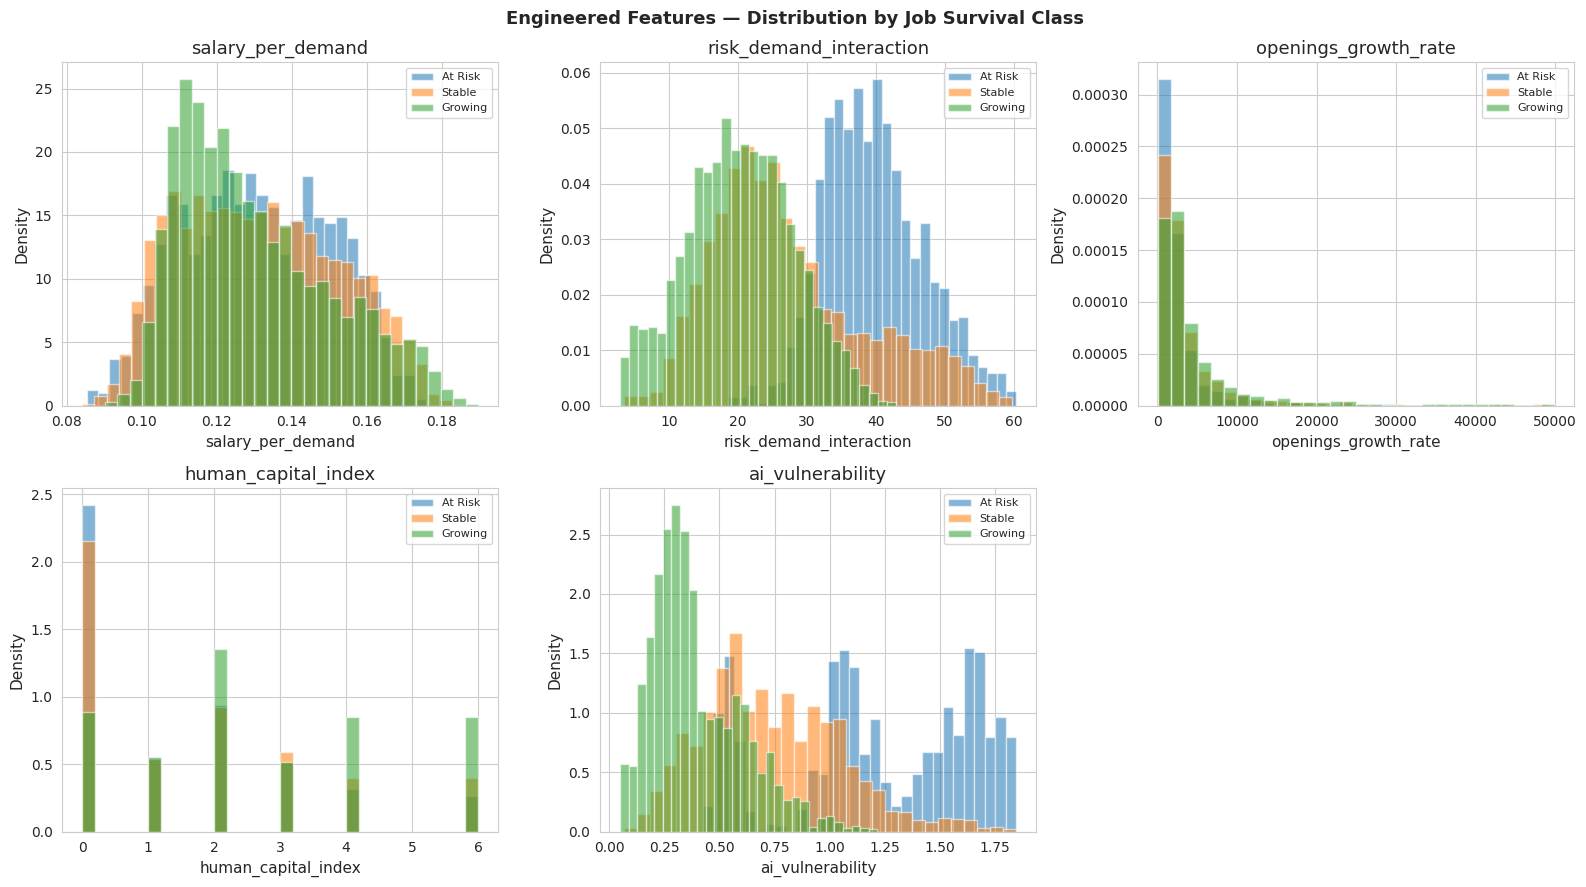

In [15]:
# Visualise the top engineered features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(NEW_FEATURES):
    for cls in sorted(y.unique()):
        mask = (y.values == cls)
        axes[i].hist(df_fe.loc[mask, feat], bins=30, alpha=0.55, label=class_labels[cls], density=True)
    axes[i].set_title(f"{feat}")
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Density")

# Hide last empty subplot
axes[-1].set_visible(False)

plt.suptitle("Engineered Features — Distribution by Job Survival Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Re-Scale Full Feature Matrix (including engineered features)

In [16]:
# Combine original encoded + new features
X_full = pd.concat([X_raw.reset_index(drop=True), df_fe[NEW_FEATURES].reset_index(drop=True)], axis=1)

print(f"Extended feature matrix: {X_full.shape[0]:,} rows × {X_full.shape[1]} features")

# Re-apply RobustScaler
scaler_full = RobustScaler()
X_full_scaled_arr = scaler_full.fit_transform(X_full)
X_full_scaled = pd.DataFrame(X_full_scaled_arr, columns=X_full.columns, index=X_full.index)

print("✅ Full feature matrix scaled with RobustScaler.")

Extended feature matrix: 12,343 rows × 37 features
✅ Full feature matrix scaled with RobustScaler.


### 3.3 Feature Importance — Random Forest

RF Train Accuracy : 0.9944
RF Test  Accuracy : 0.9654


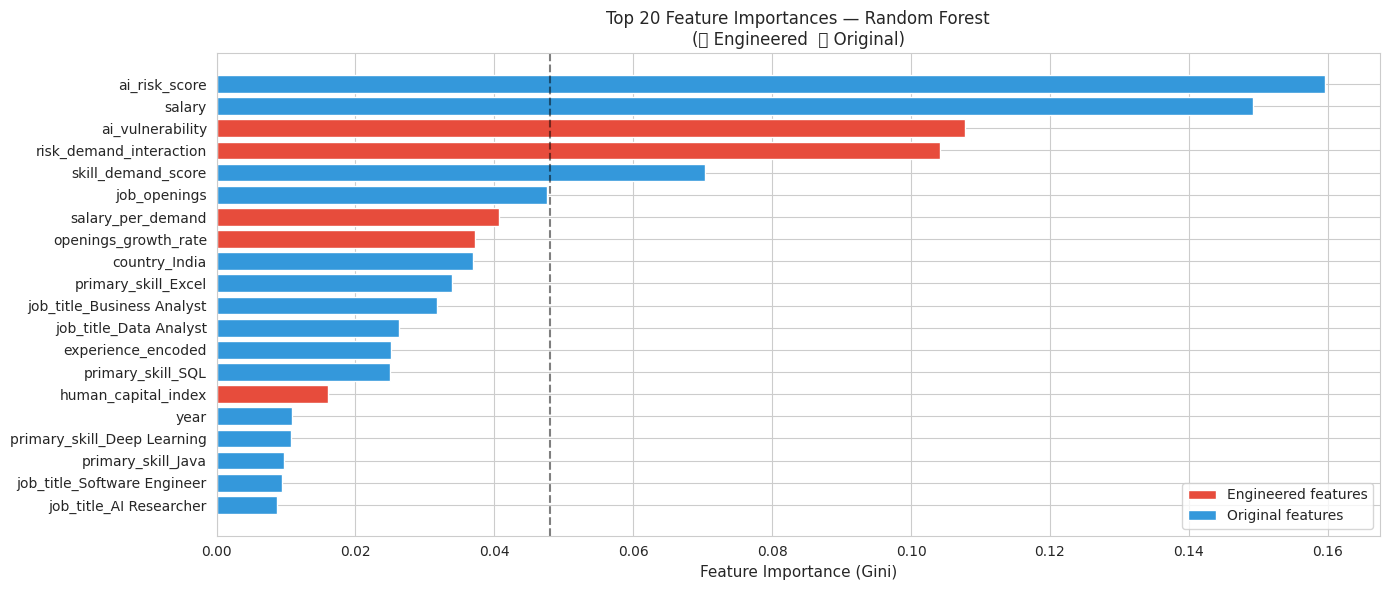


Top 15 features:
                            importance
ai_risk_score                    0.160
salary                           0.149
ai_vulnerability                 0.108
risk_demand_interaction          0.104
skill_demand_score               0.070
job_openings                     0.048
salary_per_demand                0.041
openings_growth_rate             0.037
country_India                    0.037
primary_skill_Excel              0.034
job_title_Business Analyst       0.032
job_title_Data Analyst           0.026
experience_encoded               0.025
primary_skill_SQL                0.025
human_capital_index              0.016


In [17]:
# Balance the extended matrix
X_full_bal, y_full_bal = SMOTETomek(random_state=42).fit_resample(X_full_scaled, y.reset_index(drop=True))

X_tr, X_te, y_tr, y_te = train_test_split(X_full_bal, y_full_bal,
                                            test_size=0.2, random_state=42, stratify=y_full_bal)

# Train RF for importance estimation
rf = RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

importances = pd.Series(rf.feature_importances_, index=X_full.columns).sort_values(ascending=False)

print(f"RF Train Accuracy : {rf.score(X_tr, y_tr):.4f}")
print(f"RF Test  Accuracy : {rf.score(X_te, y_te):.4f}")

# ── Plot top 20 ──
top20 = importances.head(20)
colors = ['#e74c3c' if f in NEW_FEATURES else '#3498db' for f in top20.index]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Top 20 Feature Importances — Random Forest\n(🔴 Engineered  🔵 Original)", fontsize=12)
ax.axvline(top20.values.mean(), color='black', linestyle='--', alpha=0.5, label='Mean importance')
ax.legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Engineered features'),
                   Patch(facecolor='#3498db', label='Original features')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(importances.head(15).to_frame("importance").to_string())

### 3.4 Statistical Feature Selection — ANOVA F-score (SelectKBest)

Top 20 features by ANOVA F-score:
  Feature                           F-score       p-value
  ----------------------------------------------------------
  ai_risk_score                    16510.04      0.00e+00  ✅
  ai_vulnerability                 10209.40      0.00e+00  ✅
  salary                            7483.46      0.00e+00  ✅
  risk_demand_interaction           7061.78      0.00e+00  ✅
  job_title_Business Analyst        4372.33      0.00e+00  ✅
  primary_skill_Excel               4372.33      0.00e+00  ✅
  primary_skill_SQL                 2149.38      0.00e+00  ✅
  job_title_Data Analyst            2149.38      0.00e+00  ✅
  experience_encoded                1261.30      0.00e+00  ✅
  primary_skill_Deep Learning       1234.80      0.00e+00  ✅
  job_title_AI Researcher           1234.80      0.00e+00  ✅
  primary_skill_Python               953.34      0.00e+00  ✅
  skill_demand_score                 952.90      0.00e+00  ✅
  human_capital_index                873.55      0.00e

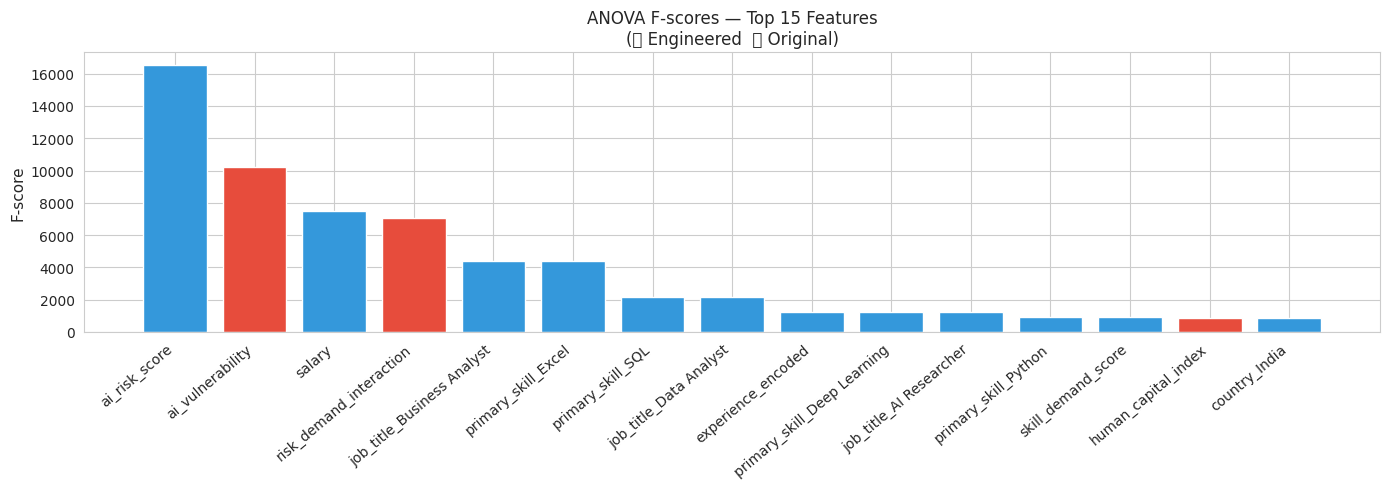

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_full_bal, y_full_bal)

f_scores = pd.Series(selector.scores_, index=X_full.columns).sort_values(ascending=False)
p_values = pd.Series(selector.pvalues_, index=X_full.columns)

print("Top 20 features by ANOVA F-score:")
print(f"  {'Feature':<30} {'F-score':>10}  {'p-value':>12}")
print("  " + "-" * 58)
for feat in f_scores.head(20).index:
    p = p_values[feat]
    sig = "✅" if p < 0.05 else "❌"
    print(f"  {feat:<30} {f_scores[feat]:>10.2f}  {p:>12.2e}  {sig}")

# ── Visualise ──
fig, ax = plt.subplots(figsize=(14, 5))
top15_f = f_scores.head(15)
clrs = ['#e74c3c' if f in NEW_FEATURES else '#3498db' for f in top15_f.index]
ax.bar(range(len(top15_f)), top15_f.values, color=clrs, edgecolor='white')
ax.set_xticks(range(len(top15_f)))
ax.set_xticklabels(top15_f.index, rotation=40, ha='right')
ax.set_title("ANOVA F-scores — Top 15 Features\n(🔴 Engineered  🔵 Original)", fontsize=12)
ax.set_ylabel("F-score")
plt.tight_layout()
plt.show()

### 3.5 Dimensionality Reduction — PCA

Original dimensions : 37
Components for 95%  : 17  (reduction: 20 features dropped)
Components for 99%  : 20


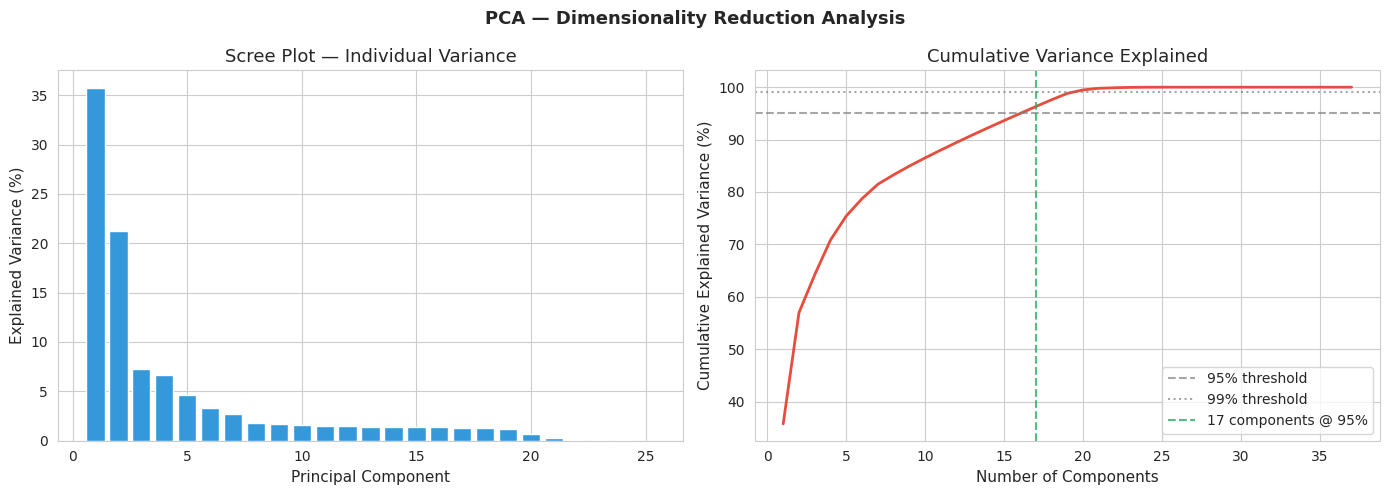


✅ PCA @ 95% variance: shape (17030, 37)  →  (17030, 17)


In [19]:
pca_full = PCA(random_state=42)
pca_full.fit(X_full_bal)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n95 = np.argmax(cumvar >= 0.95) + 1
n99 = np.argmax(cumvar >= 0.99) + 1

print(f"Original dimensions : {X_full_bal.shape[1]}")
print(f"Components for 95%  : {n95}  (reduction: {X_full_bal.shape[1]-n95} features dropped)")
print(f"Components for 99%  : {n99}")

# ── Scree plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, min(26, len(pca_full.explained_variance_ratio_)+1)),
            pca_full.explained_variance_ratio_[:25] * 100,
            color='#3498db', edgecolor='white')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot — Individual Variance")

axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, color='#e74c3c', linewidth=2)
axes[1].axhline(95, linestyle='--', color='gray', alpha=0.7, label='95% threshold')
axes[1].axhline(99, linestyle=':', color='gray', alpha=0.7, label='99% threshold')
axes[1].axvline(n95, linestyle='--', color='#27ae60', alpha=0.8, label=f'{n95} components @ 95%')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Variance Explained")
axes[1].legend()
plt.suptitle("PCA — Dimensionality Reduction Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Apply PCA @ 95% ──
pca_95 = PCA(n_components=n95, random_state=42)
X_pca_95 = pca_95.fit_transform(X_full_bal)
print(f"\n✅ PCA @ 95% variance: shape {X_full_bal.shape}  →  {X_pca_95.shape}")

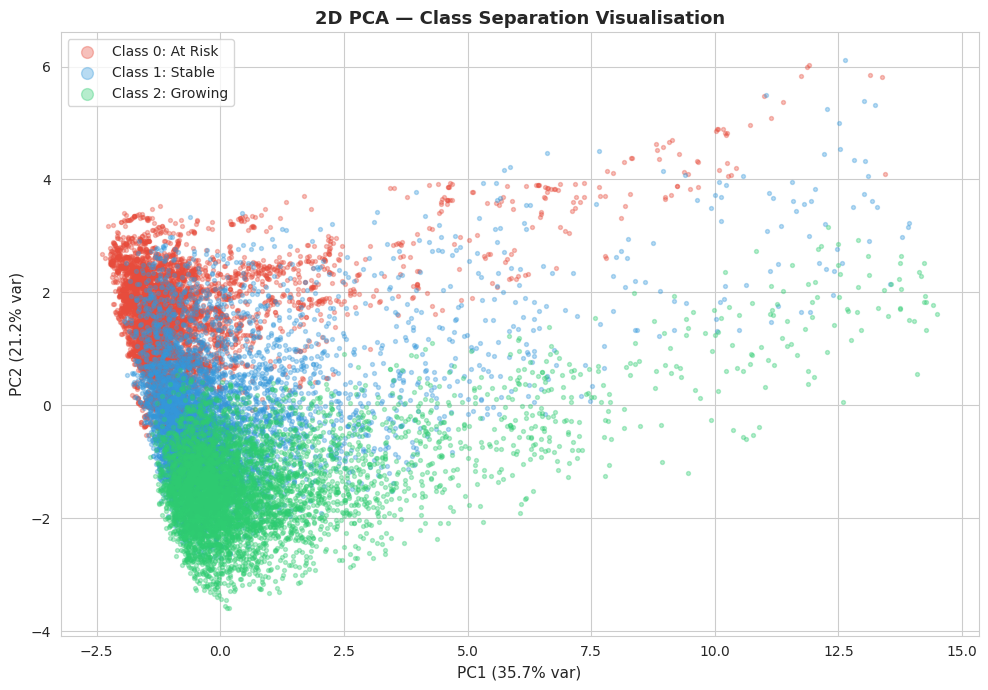

In [20]:
# 2D PCA visualisation of class separation
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_full_bal)

fig, ax = plt.subplots(figsize=(10, 7))
colors_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}
for cls in sorted(np.unique(y_full_bal)):
    mask = (y_full_bal == cls)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors_map[cls], label=f"Class {cls}: {class_labels[cls]}",
               alpha=0.35, s=8, rasterized=True)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("2D PCA — Class Separation Visualisation", fontsize=13, fontweight='bold')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

### 3.6 Correlation Heatmap — Top Features After Engineering

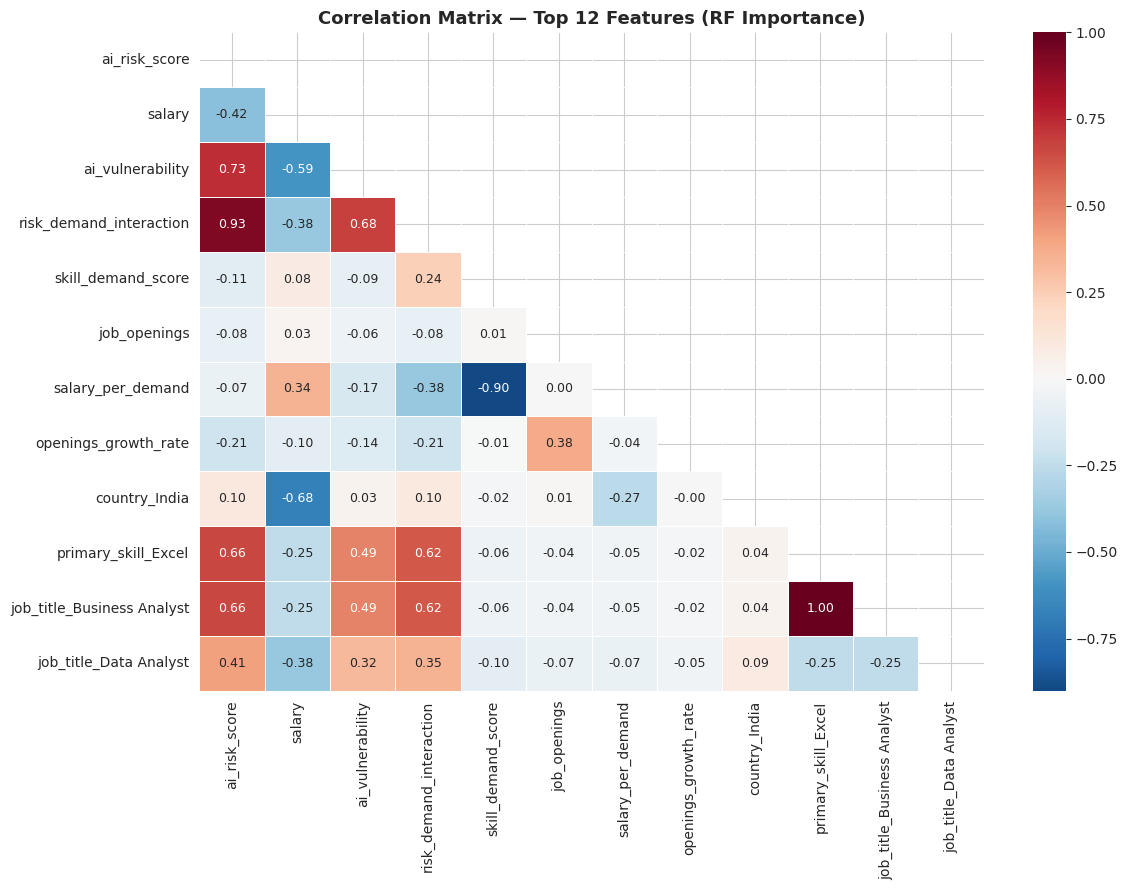

⚠️  High multicollinearity pairs (|r| > 0.85):
  ai_risk_score ↔ risk_demand_interaction  r=0.929
  skill_demand_score ↔ salary_per_demand  r=-0.901
  primary_skill_Excel ↔ job_title_Business Analyst  r=1.000


In [21]:
# Use RF importance top 12 features
top12_features = importances.head(12).index.tolist()

corr_mat = X_full_bal[top12_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask_upper = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask_upper, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5,
            ax=ax, annot_kws={"size": 9})
ax.set_title("Correlation Matrix — Top 12 Features (RF Importance)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Check for multicollinearity (|r| > 0.85)
high_corr = []
for i in range(len(corr_mat)):
    for j in range(i+1, len(corr_mat)):
        if abs(corr_mat.iloc[i,j]) > 0.85:
            high_corr.append((corr_mat.columns[i], corr_mat.columns[j], corr_mat.iloc[i,j]))

if high_corr:
    print("⚠️  High multicollinearity pairs (|r| > 0.85):")
    for a, b, r in high_corr:
        print(f"  {a} ↔ {b}  r={r:.3f}")
else:
    print("✅ No severe multicollinearity (|r| > 0.85) detected among top features.")

---
### 3.7 Final Recommended Feature Set & Pipeline Summary

In [22]:
# ── Select top-K by RF importance, validated by F-score ──
K_FEATURES = 15
top_k = importances.head(K_FEATURES).index.tolist()

print("=" * 60)
print(f"FINAL RECOMMENDED FEATURE SET  (top {K_FEATURES} by RF importance)")
print("=" * 60)
for i, feat in enumerate(top_k, 1):
    src = "🔴 engineered" if feat in NEW_FEATURES else "🔵 original  "
    imp = importances[feat]
    fs  = f_scores[feat]
    print(f"  {i:>2}. {src}  {feat:<30}  imp={imp:.4f}  F={fs:.1f}")

print()
print("=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
summary = {
    "Original samples"       : len(df),
    "After SMOTETomek"        : len(X_full_bal),
    "Original features"       : len(feature_cols),
    "After feature engineering": X_full.shape[1],
    "Selected features (RF)"  : K_FEATURES,
    "PCA components @ 95% var": n95,
    "Train samples"           : len(X_tr),
    "Test samples"            : len(X_te),
}
for k, v in summary.items():
    print(f"  {k:<35}: {v:,}")

print()
print("✅ Data is ready for modelling (Phase 4).")
print("   Use X_tr / y_tr for training, X_te / y_te for evaluation.")
print(f"   Recommended: use top {K_FEATURES} features or {n95} PCA components.")

FINAL RECOMMENDED FEATURE SET  (top 15 by RF importance)
   1. 🔵 original    ai_risk_score                   imp=0.1596  F=16510.0
   2. 🔵 original    salary                          imp=0.1493  F=7483.5
   3. 🔴 engineered  ai_vulnerability                imp=0.1078  F=10209.4
   4. 🔴 engineered  risk_demand_interaction         imp=0.1041  F=7061.8
   5. 🔵 original    skill_demand_score              imp=0.0703  F=952.9
   6. 🔵 original    job_openings                    imp=0.0475  F=490.3
   7. 🔴 engineered  salary_per_demand               imp=0.0406  F=3.7
   8. 🔴 engineered  openings_growth_rate            imp=0.0372  F=159.6
   9. 🔵 original    country_India                   imp=0.0370  F=856.3
  10. 🔵 original    primary_skill_Excel             imp=0.0339  F=4372.3
  11. 🔵 original    job_title_Business Analyst      imp=0.0318  F=4372.3
  12. 🔵 original    job_title_Data Analyst          imp=0.0263  F=2149.4
  13. 🔵 original    experience_encoded              imp=0.0250  F=1261.3

In [23]:
# ── Export prepared datasets ──
print("Exporting prepared datasets...")

# Save full balanced feature matrix + top-k selection
X_full_bal_df = pd.DataFrame(X_full_bal, columns=X_full.columns)
X_full_bal_df['target'] = y_full_bal.values

X_full_bal_df.to_csv("prepared_dataset_full.csv", index=False)
print(f"  ✅ prepared_dataset_full.csv  ({X_full_bal_df.shape[0]:,} rows × {X_full_bal_df.shape[1]} cols)")

# Top-K only
X_topk = X_full_bal_df[top_k + ['target']]
X_topk.to_csv("prepared_dataset_topk.csv", index=False)
print(f"  ✅ prepared_dataset_topk.csv  ({X_topk.shape[0]:,} rows × {X_topk.shape[1]} cols)")

print()
print("🎯 Pipeline complete! Both datasets saved and ready for Phase 4 modelling.")

Exporting prepared datasets...


  ✅ prepared_dataset_full.csv  (17,030 rows × 38 cols)


  ✅ prepared_dataset_topk.csv  (17,030 rows × 16 cols)

🎯 Pipeline complete! Both datasets saved and ready for Phase 4 modelling.
